# Exploratory Data Analysis (EDA) — Titanic Dataset

**Internship Project: Exploratory Data Analysis**

This notebook analyzes the Titanic passenger dataset to uncover patterns and trends
related to passenger survival. It covers:

1. Data loading & structure
2. Statistical summaries
3. Data cleaning
4. Univariate & bivariate visualizations
5. Correlation analysis
6. Key insights & conclusions

**Dataset:** 891 passengers from the RMS Titanic (1912), including demographic and
ticket information, with the target variable `Survived` (0 = Died, 1 = Survived).


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline


## 2. Load the Dataset

In [2]:
df = pd.read_csv("../data/titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Understand the Structure

In [3]:
print("Shape of dataset:", df.shape)
df.info()


Shape of dataset: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### Missing Values

Checking for missing data is a critical first EDA step — it determines how we clean
and what caveats apply to later analysis.

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


Cabin       687
Age         177
Embarked      2
dtype: int64

**Observation:** `Cabin` is missing for ~77% of passengers (too sparse to use
reliably), `Age` is missing for ~20%, and `Embarked` is missing for 2 records.

## 4. Data Cleaning & Feature Engineering

- Fill missing `Age` with the median (robust to outliers).
- Fill missing `Embarked` with the most frequent port.
- Create `AgeGroup` for easier categorical comparison.
- Create `FamilySize` = SibSp + Parch + 1 (siblings/spouses + parents/children + self).

In [6]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                         labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df[["Age", "Embarked", "AgeGroup", "FamilySize"]].head()


,Age,Embarked,AgeGroup,FamilySize
0,22.0,S,Young Adult,2
1,38.0,C,Adult,2
2,26.0,S,Young Adult,1
3,35.0,S,Young Adult,2
4,35.0,S,Young Adult,1


## 5. Univariate Analysis

### 5.1 Overall Survival Rate

Overall survival rate: 38.4%


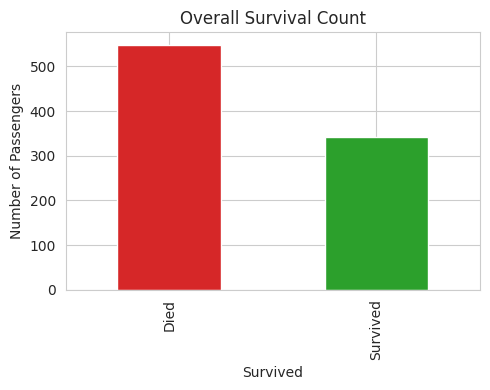

In [7]:
survival_counts = df["Survived"].value_counts()
survival_rate = df["Survived"].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
survival_counts.rename({0: "Died", 1: "Survived"}).plot(
    kind="bar", color=["#d62728", "#2ca02c"], ax=ax)
ax.set_title("Overall Survival Count")
ax.set_ylabel("Number of Passengers")
plt.tight_layout()
plt.show()


**Observation:** Only about 38% of passengers survived — a majority did not.

### 5.2 Age Distribution

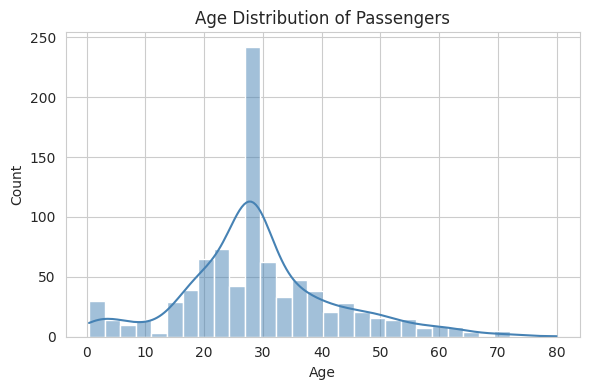

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="Age", kde=True, bins=30, ax=ax, color="steelblue")
ax.set_title("Age Distribution of Passengers")
plt.tight_layout()
plt.show()


## 6. Bivariate Analysis — Key Influencing Factors

### 6.1 Survival by Sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


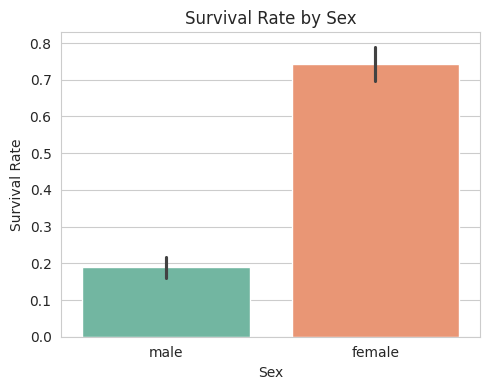

In [9]:
sex_survival = df.groupby("Sex")["Survived"].mean()
print(sex_survival)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=df, x="Sex", y="Survived", hue="Sex", legend=False, ax=ax, palette="Set2")
ax.set_title("Survival Rate by Sex")
ax.set_ylabel("Survival Rate")
plt.tight_layout()
plt.show()


**Observation:** Females had a dramatically higher survival rate (~74%) than
males (~19%) — consistent with the "women and children first" evacuation policy.

### 6.2 Survival by Passenger Class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


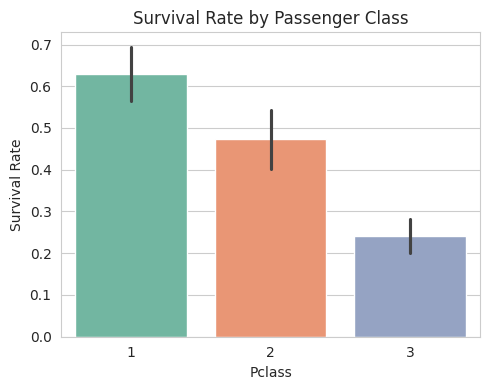

In [10]:
class_survival = df.groupby("Pclass")["Survived"].mean()
print(class_survival)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Pclass", legend=False, ax=ax, palette="Set2")
ax.set_title("Survival Rate by Passenger Class")
ax.set_ylabel("Survival Rate")
plt.tight_layout()
plt.show()


**Observation:** 1st class passengers survived at far higher rates (~63%) than
3rd class (~24%) — socioeconomic status strongly influenced survival, likely tied to
cabin location and lifeboat access.

### 6.3 Age Distribution by Survival

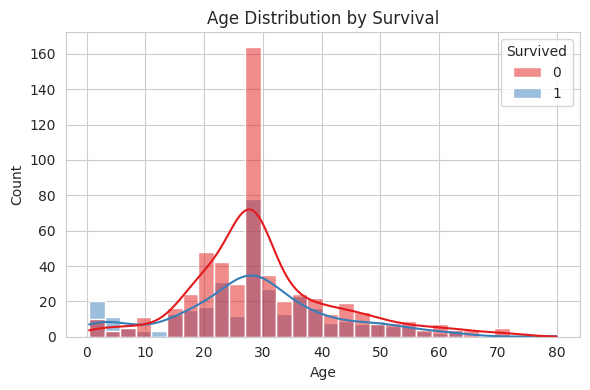

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="Age", hue="Survived", kde=True, bins=30, ax=ax, palette="Set1")
ax.set_title("Age Distribution by Survival")
plt.tight_layout()
plt.show()


**Observation:** Young children had noticeably higher survival rates than other age groups.

### 6.4 Fare vs Survival

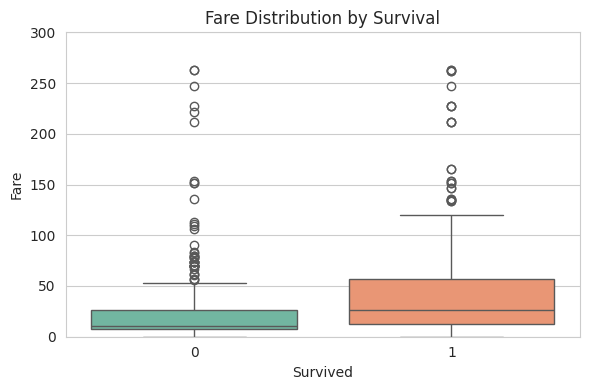

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Survived", y="Fare", hue="Survived", legend=False, ax=ax, palette="Set2")
ax.set_ylim(0, 300)
ax.set_title("Fare Distribution by Survival")
plt.tight_layout()
plt.show()


**Observation:** Survivors tended to have paid higher fares, reinforcing the class effect above.

### 6.5 Survival by Embarkation Port

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


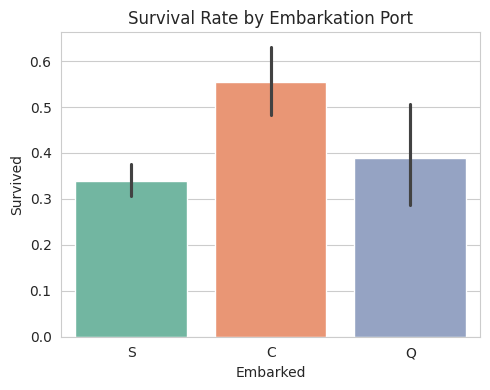

In [13]:
embarked_survival = df.groupby("Embarked")["Survived"].mean()
print(embarked_survival)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=df, x="Embarked", y="Survived", hue="Embarked", legend=False, ax=ax, palette="Set2")
ax.set_title("Survival Rate by Embarkation Port")
plt.tight_layout()
plt.show()


### 6.6 Survival by Family Size

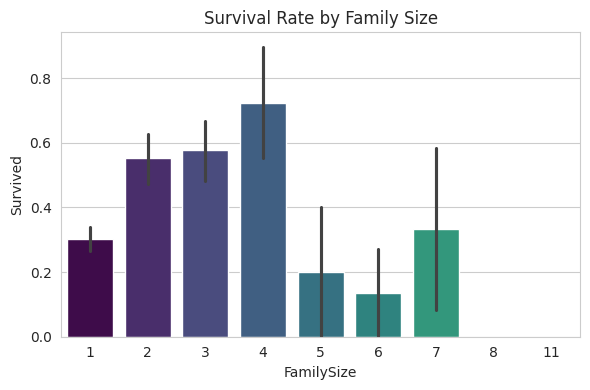

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df, x="FamilySize", y="Survived", hue="FamilySize", legend=False, ax=ax, palette="viridis")
ax.set_title("Survival Rate by Family Size")
plt.tight_layout()
plt.show()


**Observation:** Passengers traveling with a small family (2-4 members) survived
more often than those traveling completely alone or with very large families.

## 7. Correlation Analysis

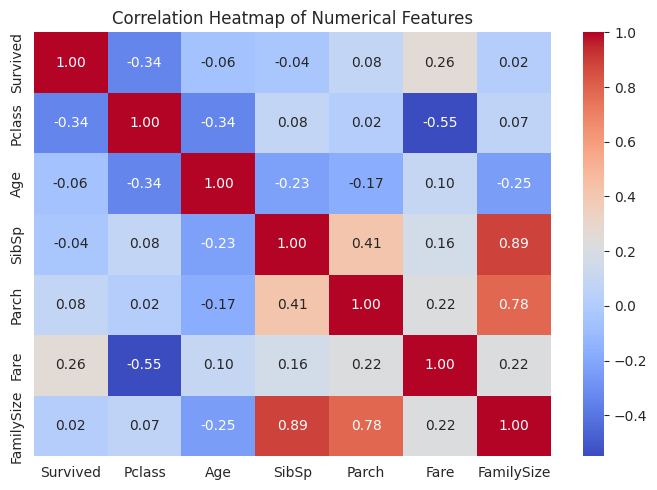

Survived      1.000000
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.064910
Pclass       -0.338481
Name: Survived, dtype: float64

In [15]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

corr["Survived"].sort_values(ascending=False)


**Observation:** `Pclass` has the strongest negative correlation with survival
(-0.34) and `Fare` the strongest positive correlation (+0.26) among numeric features —
both point to socioeconomic status as a key driver of survival.

### 7.1 Pairwise Relationships

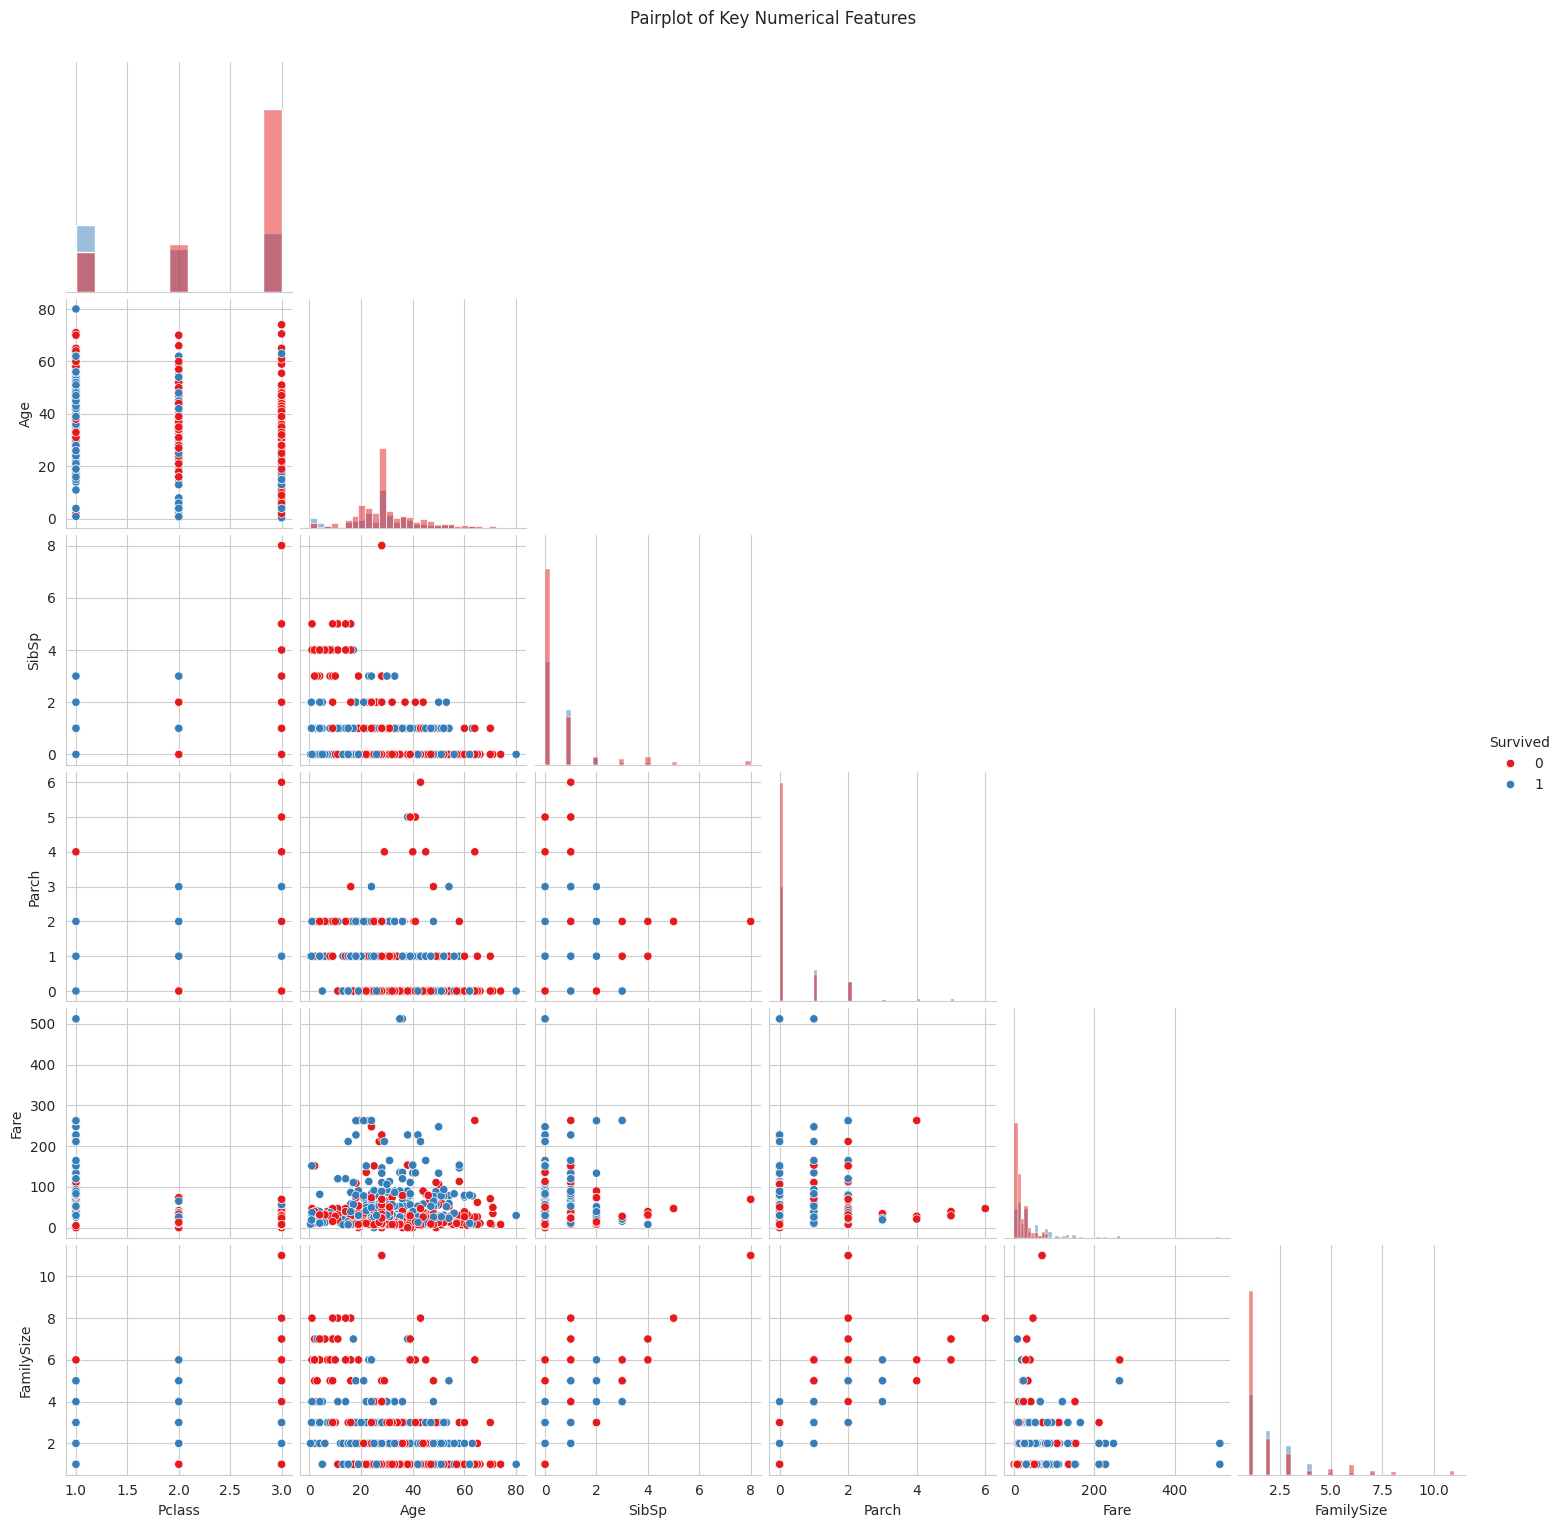

In [16]:
g = sns.pairplot(df[num_cols].dropna(), hue="Survived", palette="Set1",
                  corner=True, diag_kind="hist")
g.fig.suptitle("Pairplot of Key Numerical Features", y=1.02)
plt.show()


## 8. Key Insights & Conclusion

1. **Sex was the single strongest predictor of survival** — women survived at ~74%
   vs. ~19% for men.
2. **Passenger class (socioeconomic status) was the strongest numeric correlate**
   of survival — 1st class passengers survived at roughly 2.5x the rate of 3rd class.
3. **Fare correlates positively with survival**, reinforcing the class effect (fare
   is essentially a proxy for class and cabin location).
4. **Children had a survival advantage** over adults, consistent with evacuation
   priority policies.
5. **Moderate family size (2-4 people) was protective** compared to traveling alone
   or in very large families, possibly reflecting mutual assistance during evacuation
   vs. the difficulty of coordinating large groups.
6. **Port of embarkation** showed some variation in survival rate, largely driven by
   the class composition of passengers boarding at each port (Cherbourg had a higher
   proportion of 1st class passengers).

**Overall:** Survival on the Titanic was driven primarily by a combination of
**sex, socioeconomic class, and age**, reflecting both the era's social norms
("women and children first") and practical realities of cabin location and
lifeboat access for wealthier passengers.
